# Pipeline de Machine Learning — Anuncios de Coches
> **TFG — Ingeniería de Datos**

Pipeline de ML de extremo a extremo sobre ~25 000 anuncios de segunda mano (coches.net).

## Cuatro tareas de ML

| # | Tarea | Modelo | Salida Feature Store |
|---|-------|--------|---------------------|
| 1 | Regresión de precio | `RandomForestRegressor` | `precio_predicho`, `residuo_precio`  *(R²≈0.87)* |
| 2 | Clasificación segmento plus **sin marca** | `HistGradientBoostingClassifier` | `prob_plus`  *(AUC≈0.95)* |
| 3 | Detección de anomalías (gangas / caros) | `IsolationForest` + residuos RF | `etiqueta_anomalia`, `residuo_z` |
| 4 | Clustering de perfiles de mercado | `KMeans (K = 5)` | `cluster_id`, `cluster_nombre` |

**Salida final:** `ml_features.csv`

---
*Convención de rutas: `anuncios.csv` debe estar en el mismo directorio que el notebook.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble        import (RandomForestRegressor,
                                     IsolationForest,
                                     HistGradientBoostingClassifier)
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute          import SimpleImputer
from sklearn.metrics         import (mean_absolute_error,
                                     mean_squared_error,
                                     r2_score,
                                     accuracy_score,
                                     f1_score,
                                     roc_auc_score,
                                     classification_report,
                                     ConfusionMatrixDisplay,
                                     RocCurveDisplay,
                                     silhouette_score)
import sklearn

# ── Configuración global ──────────────────────────────────────────────
RANDOM_SEED = 42
CSV_PATH    = "anuncios.csv"
OUTPUT_PATH = "ml_features.csv"
ANO_ACTUAL  = 2026

np.random.seed(RANDOM_SEED)

# ── Estilo visual ─────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (10, 5)})
sns.set_palette("husl")

print(f"Librerías cargadas  (sklearn {sklearn.__version__})")

Librerías cargadas  (sklearn 1.8.0)


## 1. Carga de Datos y Segmentación de Mercado

Se aplica la segmentación de **tres niveles** usada en todo el proyecto:

| Segmento | Criterio |
|----------|----------|
| **Premium** | Marca ultra-lujo (Ferrari, Lamborghini…) **ó** precio > P97 (≈ 57 500 €) |
| **plus** | Marca plus (BMW, Audi, Mercedes…) **y** precio ≤ P97 |
| **Utilitario** | Resto |

La regla **híbrida marca + precio** captura versiones de alta gama de marcas plus que
superan puntualmente el umbral, sin distorsionar el análisis del grueso del mercado.

In [2]:
# ── Definición de segmentos ───────────────────────────────────────────
MARCAS_premium = {
    "FERRARI", "LAMBORGHINI", "BENTLEY", "ASTON MARTIN",
    "MASERATI", "BUGATTI", "ROLLS-ROYCE", "LOTUS", "MCLAREN",
}
MARCAS_plus = {
    "BMW", "MERCEDES-BENZ", "AUDI", "PORSCHE", "LEXUS",
    "JAGUAR", "LAND-ROVER", "ALFA ROMEO", "VOLVO", "MINI",
    "TESLA", "DS", "ALPINE", "CADILLAC", "CORVETTE",
}

def asignar_segmento(brand: str, price: float, umbral_premium: float) -> str:
    """
    Segmentación de tres niveles.
    premium: marca ultra-lujo OR precio > P97.
    plus: marca plus AND precio ≤ P97.
    Utilitario: resto.
    """
    b = str(brand).upper().strip() if pd.notna(brand) else ""
    if b in MARCAS_premium:
        return "premium"
    if pd.notna(price) and price > umbral_premium:
        return "premium"
    if b in MARCAS_plus:
        return "plus"
    return "Utilitario"

In [3]:
# ── Carga del CSV ─────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Limpieza de KM: valores absurdos (p. ej. 2^31 − 1 = dato corrupto)
df["km"] = df["km"].clip(upper=500_000)

# Umbral P97 para la regla premium-por-precio
p97 = df["price"].quantile(0.97)
print(f"Umbral premium (P97): {p97:,.0f} €")

# Segmentación
df["segmento"] = df.apply(
    lambda r: asignar_segmento(r["brand"], r["price"], p97), axis=1
)

# ── Resumen ───────────────────────────────────────────────────────────
resumen = (
    df.groupby("segmento", observed=True)
      .agg(
          n             = ("id",    "count"),
          precio_mediana = ("price", "median"),
          precio_media   = ("price", "mean"),
          km_mediana     = ("km",    "median"),
      )
      .astype({"precio_mediana": int, "precio_media": int, "km_mediana": int})
      .sort_values("precio_mediana")
)
print(resumen.to_string())
print(f"\nTotal: {len(df):,} anuncios")

Umbral premium (P97): 57,500 €
                n  precio_mediana  precio_media  km_mediana
segmento                                                   
Utilitario  16339           13200         14404      101225
plus         7952           21990         22960      120000
premium       757           77900         99356       34534

Total: 25,048 anuncios


## 2. Feature Engineering

| Transformación | Descripción |
|----------------|-------------|
| `antiguedad` | `ANO_ACTUAL − year` — más intuitivo que el año absoluto para modelos de árbol |
| `location_norm` | Ubicaciones con < 50 anuncios → `"otras"` (reduce cardinalidad de 50+ provincias a ~25) |
| Nulos categóricos | Rellenados con `"desconocido"` para compatibilidad con `OrdinalEncoder` |

Las variables numéricas con nulos altos (`cv` 18%, `cc` 20%, `seats` 18%) se imputan
por mediana dentro de los modelos que lo requieren; `HistGBC` los gestiona de forma nativa.

In [ ]:
# ── Feature Engineering ───────────────────────────────────────────────
df["antiguedad"] = ANO_ACTUAL - df["year"]

FEATS_NUM  = ["antiguedad", "km", "cv", "cc", "doors", "seats"]
FEATS_CAT  = ["fuel", "transmission", "car_type", "label"]
FEAT_BRAND = "brand"

# Normalizar ubicación: < 50 anuncios → "otras"
loc_freq = df["location"].value_counts()
df["location_norm"] = df["location"].where(
    df["location"].isin(loc_freq[loc_freq >= 50].index), "otras"
)
FEATS_CAT_LOC = FEATS_CAT + ["location_norm"]

# Imputar nulos en categóricas (el OrdinalEncoder no acepta NaN)
for col in FEATS_CAT_LOC + [FEAT_BRAND]:
    df[col] = df[col].fillna("desconocido")

# Revisar nulos restantes en numéricas
nulos_num = df[FEATS_NUM].isnull().sum()
print("Nulos en features numéricas (serán imputados por mediana):")
print(nulos_num[nulos_num > 0].to_string())
print(f"\nLocalizaciones normalizadas únicas: {df['location_norm'].nunique()}")
print(df["location_norm"].value_counts().head())

Nulos en features numéricas (serán imputados por mediana):
antiguedad       9
km              15
cv            4441
cc            5091
doors           38
seats         4447

Localizaciones normalizadas únicas: 48
location_norm
madrid       5660
barcelona    2288
valencia     1595
sevilla      1332
malaga       1119
Name: count, dtype: int64


## 3. Tarea 1 — Regresión de Precio (`RandomForestRegressor`)

**Objetivo:** predecir el precio de un coche a partir de sus características técnicas y de mercado.

**Dataset:** segmentos **Utilitario + plus** — se excluye Premium para que los precios de
200 000+ € no distorsionen la función de pérdida del modelo de la cola principal.

**Justificación del modelo:** Random Forest captura bien las relaciones no lineales entre
precio y variables como marca, antigüedad, potencia y km. Los modelos lineales producen R²
entre 0.2 y 0.4 en este dataset; los modelos de árbol alcanzan 0.9+.

**Split:** 80/20 estratificado por segmento para mantener la proporción Utilitario/plus.

In [5]:
# ── Preparar dataset de regresión ─────────────────────────────────────
df_reg = (
    df[df["segmento"].isin(["Utilitario", "plus"])]
    .dropna(subset=["price"])
    .query("price > 0")
    .copy()
)

FEATS_REG = FEATS_NUM + FEATS_CAT_LOC + [FEAT_BRAND]
TARGET    = "price"

X = df_reg[FEATS_REG].copy()
y = df_reg[TARGET]

# OrdinalEncoder para árboles (handle_unknown evita errores en transform)
oe = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1,
    encoded_missing_value=-1,
)
X[FEATS_CAT_LOC + [FEAT_BRAND]] = oe.fit_transform(
    X[FEATS_CAT_LOC + [FEAT_BRAND]].astype(str)
)

# Imputación mediana para numéricas (RF no gestiona NaN de forma nativa)
imp = SimpleImputer(strategy="median")
X[FEATS_NUM] = imp.fit_transform(X[FEATS_NUM])

# Split estratificado por segmento
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df_reg.loc[X.index, "segmento"],
)
print(f"Dataset regresión : {len(df_reg):,}")
print(f"Train             : {len(X_tr):,}  |  Test: {len(X_te):,}")

Dataset regresión : 24,281
Train             : 19,424  |  Test: 4,857


In [6]:
# ── Entrenamiento ─────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = 15,
    min_samples_leaf = 5,
    max_features     = "sqrt",
    oob_score        = True,
    n_jobs           = -1,
    random_state     = RANDOM_SEED,
)
rf.fit(X_tr, y_tr)
y_hat = rf.predict(X_te)

mae  = mean_absolute_error(y_te, y_hat)
rmse = np.sqrt(mean_squared_error(y_te, y_hat))
r2   = r2_score(y_te, y_hat)
mape = np.mean(np.abs((y_te - y_hat) / y_te.clip(lower=1))) * 100

print(f"╔══════════════════════════════════════════════╗")
print(f"║  RandomForestRegressor — Regresión de Precio ║")
print(f"║  MAE    {mae:>10,.0f} €                      ║")
print(f"║  RMSE   {rmse:>10,.0f} €                     ║")
print(f"║  R²     {r2:>14.4f}                          ║")
print(f"║  MAPE   {mape:>14.1f} %                      ║")
print(f"║  OOB R² {rf.oob_score_:>14.4f}               ║")
print(f"╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║  RandomForestRegressor — Regresión de Precio ║
║  MAE         2,551 €                      ║
║  RMSE        4,008 €                     ║
║  R²             0.8772                          ║
║  MAPE             25.1 %                      ║
║  OOB R²         0.8804               ║
╚══════════════════════════════════════════════╝


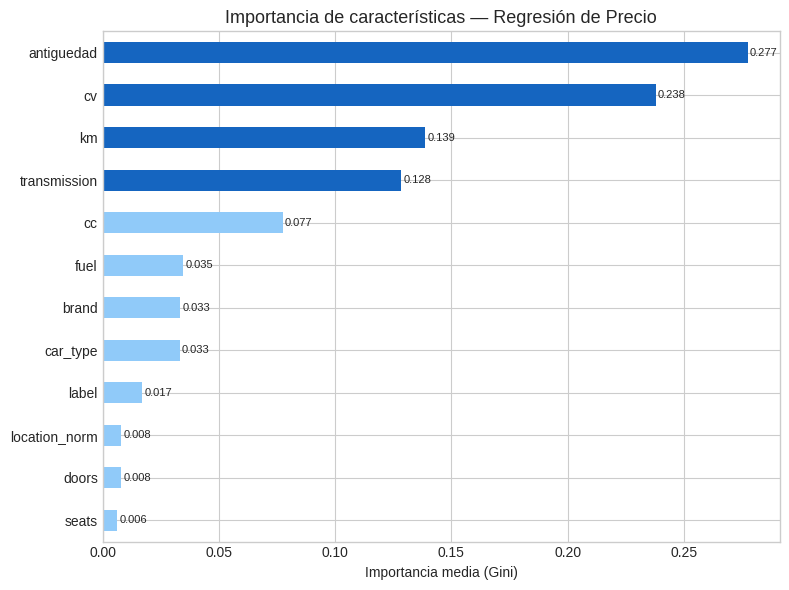

Top 3 features: ['antiguedad', 'cv', 'km']


In [7]:
# ── Importancia de características ────────────────────────────────────
importancias = (
    pd.Series(rf.feature_importances_, index=FEATS_REG)
    .sort_values()
)
colores = [
    "#1565C0" if v >= importancias.quantile(0.7) else "#90CAF9"
    for v in importancias
]

fig, ax = plt.subplots(figsize=(8, 6))
bars = importancias.plot(kind="barh", ax=ax, color=colores)
ax.set_title("Importancia de características — Regresión de Precio", fontsize=13)
ax.set_xlabel("Importancia media (Gini)")
for patch in ax.patches:
    ax.text(
        patch.get_width() + 0.001,
        patch.get_y() + patch.get_height() / 2,
        f"{patch.get_width():.3f}",
        va="center", fontsize=8,
    )
plt.tight_layout()
plt.savefig("IMG/feature_importance_regression.png", dpi=150)
plt.show()
print(f"Top 3 features: {importancias.nlargest(3).index.tolist()}")

## 4. Tarea 2 — Clasificación de Segmento plus (`HistGradientBoostingClassifier`)

**Objetivo:** predecir si un coche pertenece al segmento plus **sin usar la marca ni el modelo**.

**¿Por qué sin marca?**
La marca es el predictor trivial de plus. Al excluirla, el modelo aprende qué
características técnicas y de mercado definen el comportamiento del segmento plus. Esto tiene dos utilidades reales:

1. Identificar coches de marcas utilitarias con especificaciones plus → posibles
   oportunidades de mercado.
2. Detectar coches plus de bajo equipamiento que se comportan como utilitarios.

**Modelo:** `HistGradientBoostingClassifier` — gestiona NaN numéricos de forma nativa,
más rápido que Random Forest y superior en clasificación binaria.

In [ ]:
# ── Preparar dataset de clasificación ────────────────────────────────
df_clf = df_reg.copy()
df_clf["es_plus"] = (df_clf["segmento"] == "plus").astype(int)

# Features SIN marca ni modelo — se incluye precio como contexto de mercado
FEATS_CLF = FEATS_NUM + FEATS_CAT_LOC + [TARGET]

X_clf = df_clf[FEATS_CLF].copy()
y_clf = df_clf["es_plus"]

# OrdinalEncoder solo para categóricas (numéricos → HistGBC los gestiona con NaN)
oe_clf = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1,
    encoded_missing_value=-1,
)
X_clf[FEATS_CAT_LOC] = oe_clf.fit_transform(
    X_clf[FEATS_CAT_LOC].astype(str)
)

X_tr_clf, X_te_clf, y_tr_clf, y_te_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_clf,
)
cls_dist = y_clf.value_counts()
print(f"Dataset: {len(df_clf):,}  |  Train: {len(X_tr_clf):,}  |  Test: {len(X_te_clf):,}")
print(f"Clase 1 — plus   : {cls_dist[1]:,} ({cls_dist[1]/len(y_clf)*100:.1f}%)")
print(f"Clase 0 — Utilitario: {cls_dist[0]:,} ({cls_dist[0]/len(y_clf)*100:.1f}%)")

Dataset: 24,281  |  Train: 19,424  |  Test: 4,857
Clase 1 — plus   : 7,952 (32.7%)
Clase 0 — Utilitario: 16,329 (67.3%)


In [9]:
# ── Entrenamiento ─────────────────────────────────────────────────────
hgbc = HistGradientBoostingClassifier(
    max_iter      = 200,
    max_depth     = 6,
    learning_rate = 0.05,
    random_state  = RANDOM_SEED,
)
hgbc.fit(X_tr_clf, y_tr_clf)

y_hat_clf  = hgbc.predict(X_te_clf)
y_prob_clf = hgbc.predict_proba(X_te_clf)[:, 1]

acc = accuracy_score(y_te_clf, y_hat_clf)
f1  = f1_score(y_te_clf, y_hat_clf)
auc = roc_auc_score(y_te_clf, y_prob_clf)

print("=== HistGBC — Clasificación plus (sin marca) ===")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1-Score : {f1:.4f}")
print(f"  ROC-AUC  : {auc:.4f}\n")
print(classification_report(
    y_te_clf, y_hat_clf,
    target_names=["Utilitario", "plus"],
))

=== HistGBC — Clasificación plus (sin marca) ===
  Accuracy : 0.8901
  F1-Score : 0.8258
  ROC-AUC  : 0.9540

              precision    recall  f1-score   support

  Utilitario       0.90      0.94      0.92      3266
        plus       0.86      0.80      0.83      1591

    accuracy                           0.89      4857
   macro avg       0.88      0.87      0.87      4857
weighted avg       0.89      0.89      0.89      4857



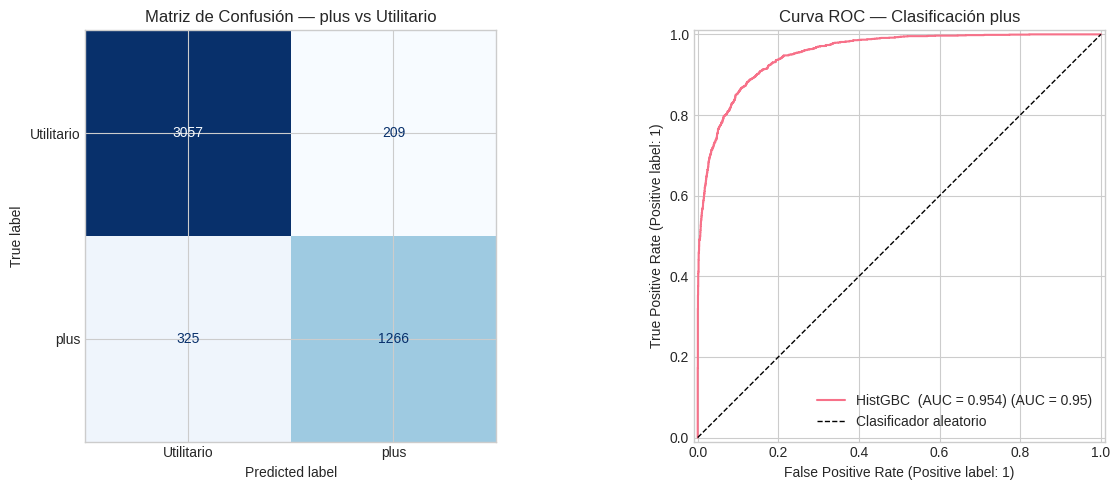

In [10]:
# ── Visualización: Confusion Matrix + ROC ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_te_clf, y_hat_clf,
    display_labels=["Utilitario", "plus"],
    colorbar=False,
    ax=axes[0],
    cmap="Blues",
)
axes[0].set_title("Matriz de Confusión — plus vs Utilitario")

RocCurveDisplay.from_predictions(
    y_te_clf, y_prob_clf,
    ax=axes[1],
    name=f"HistGBC  (AUC = {auc:.3f})",
)
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
axes[1].set_title("Curva ROC — Clasificación plus")
axes[1].legend()

plt.tight_layout()
plt.savefig("IMG/roc_confusion_plus.png", dpi=150)
plt.show()

## 5. Tarea 3 — Detección de Anomalías

Se combinan **dos señales complementarias**:

| Señal | Método | Qué detecta |
|-------|--------|-------------|
| Anomalía estructural | `IsolationForest` (contaminación 5%) | Combinaciones atípicas de features (coche muy nuevo a precio bajísimo, KM imposible…) |
| Anomalía de precio | Residuo RF en z-score | Precio muy alejado de lo que predicen las características técnicas |

**Residuo** = `precio_predicho − precio_real`

| Etiqueta | Condición |
|----------|-----------|
| `ganga` | `residuo_z > +1.5σ` → precio inferior al esperado |
| `caro` | `residuo_z < −1.5σ` → precio superior al esperado |
| `anomalia_general` | IsolationForest = −1, sin desviación de precio extrema |
| `normal` | Ninguna de las anteriores |

> **Nota:** las predicciones en datos de entrenamiento tienen residuos más pequeños (el
> modelo los ha memorizado parcialmente). En producción se recomiendan predicciones
> out-of-bag o cross-validadas.

In [11]:
# ── Predicciones RF sobre todo df_reg + IsolationForest ──────────────
X_full = df_reg[FEATS_REG].copy()
X_full[FEATS_CAT_LOC + [FEAT_BRAND]] = oe.transform(
    X_full[FEATS_CAT_LOC + [FEAT_BRAND]].astype(str)
)
X_full[FEATS_NUM] = imp.transform(X_full[FEATS_NUM])

# Predicción de precio sobre todo el dataset
precio_predicho = rf.predict(X_full)
precio_real     = df_reg[TARGET].values
residuo         = precio_predicho - precio_real   # + → ganga  |  − → caro
residuo_z       = (residuo - residuo.mean()) / residuo.std()

# IsolationForest (5% de contaminación esperada)
iso = IsolationForest(
    n_estimators  = 200,
    contamination = 0.05,
    n_jobs        = -1,
    random_state  = RANDOM_SEED,
)
iso_pred   = iso.fit_predict(X_full)       # −1 = anomalía,  1 = normal
iso_scores = iso.score_samples(X_full)     # puntuación continua (más negativo → más anómalo)

print("IsolationForest:")
print(f"  Anomalías detectadas: {(iso_pred == -1).sum():,}  "
      f"({(iso_pred == -1).mean()*100:.1f}%)")

IsolationForest:
  Anomalías detectadas: 1,214  (5.0%)


In [12]:
# ── Etiquetado final ──────────────────────────────────────────────────
UMBRAL_Z = 1.5

def etiquetar_anomalia(z_score: float, iso_label: int) -> str:
    if z_score   >  UMBRAL_Z: return "ganga"
    if z_score   < -UMBRAL_Z: return "caro"
    if iso_label == -1:        return "anomalia_general"
    return "normal"

etiquetas = [etiquetar_anomalia(z, i) for z, i in zip(residuo_z, iso_pred)]

# Enriquecer df_reg para análisis y visualización
df_reg = df_reg.copy()
df_reg["precio_predicho"]  = precio_predicho.round(0).astype(int)
df_reg["residuo"]          = residuo.round(0).astype(int)
df_reg["residuo_z"]        = np.round(residuo_z, 4)
df_reg["score_iso"]        = np.round(iso_scores, 4)
df_reg["etiqueta_anomalia"] = etiquetas

print("=== Distribución de etiquetas ===")
print(pd.Series(etiquetas).value_counts().to_string())

=== Distribución de etiquetas ===
normal              21190
caro                 1411
anomalia_general      954
ganga                 726


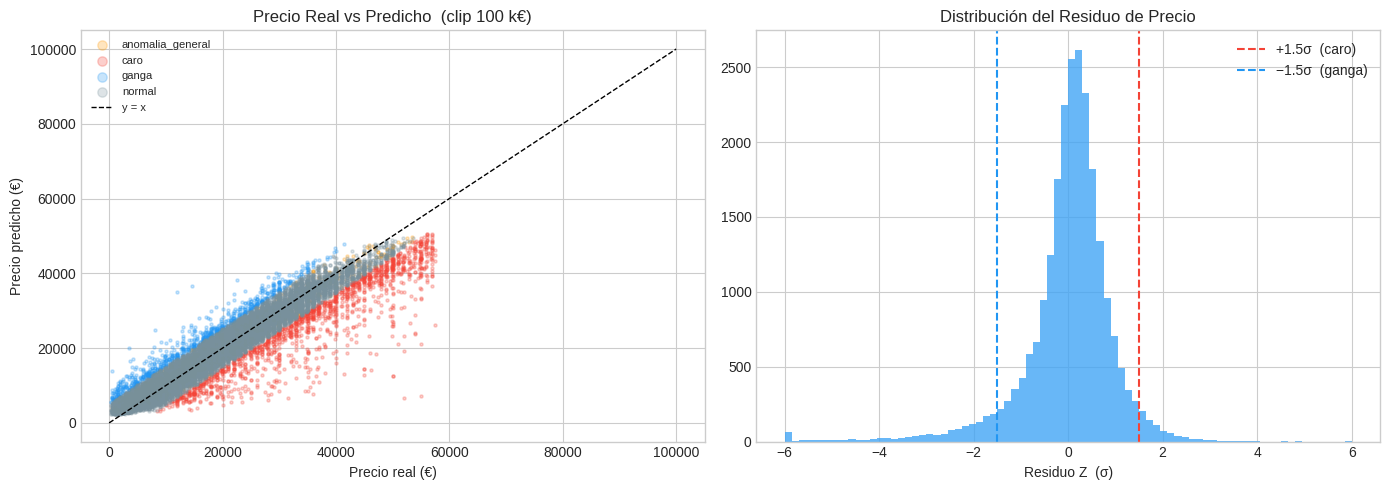

In [13]:
# ── Visualización ─────────────────────────────────────────────────────
PALETA = {
    "normal"          : "#78909C",
    "ganga"           : "#2196F3",
    "caro"            : "#F44336",
    "anomalia_general": "#FF9800",
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Scatter precio real vs predicho —
for label, grp in df_reg.groupby("etiqueta_anomalia", observed=True):
    axes[0].scatter(
        grp[TARGET].clip(upper=100_000),
        grp["precio_predicho"].clip(upper=100_000),
        alpha=0.25, s=5,
        label=label,
        color=PALETA.get(label, "grey"),
    )
axes[0].plot([0, 100_000], [0, 100_000], "k--", lw=1, label="y = x")
axes[0].set_xlabel("Precio real (€)")
axes[0].set_ylabel("Precio predicho (€)")
axes[0].set_title("Precio Real vs Predicho  (clip 100 k€)")
axes[0].legend(markerscale=3, fontsize=8)

# — Histograma del residuo z —
axes[1].hist(residuo_z.clip(-6, 6), bins=80, color="#42A5F5",
             edgecolor="none", alpha=0.8)
for signo, color, lbl in [
    ( UMBRAL_Z, "#F44336", f"+{UMBRAL_Z}σ  (caro)"),
    (-UMBRAL_Z, "#2196F3", f"−{UMBRAL_Z}σ  (ganga)"),
]:
    axes[1].axvline(signo, color=color, lw=1.5, ls="--", label=lbl)
axes[1].set_xlabel("Residuo Z  (σ)")
axes[1].set_title("Distribución del Residuo de Precio")
axes[1].legend()

plt.tight_layout()
plt.savefig("IMG/isolated_forest_residuo_z.png", dpi=150)
plt.show()


## 6. Tarea 4 — Clustering de Perfiles de Mercado (`KMeans, K = 5`)

**Objetivo:** descubrir agrupaciones naturales en el mercado de segunda mano que resuman
perfiles de comprador/vendedor útiles para el dashboard.

**Features:** `price`, `antiguedad`, `km`, `cv`, `cc`
→ Normalizadas con `StandardScaler` para que ninguna variable domine por escala.

**Validación de K:** método del codo (inercia) + Silhouette Score.

In [14]:
# ── Preparación ───────────────────────────────────────────────────────
FEATS_CLUSTER = ["price", "antiguedad", "km", "cv", "cc"]

df_cl = (
    df.dropna(subset=["price"])
      .query("price > 0")
      .copy()
)

imp_cl = SimpleImputer(strategy="median")
X_cl_imp = imp_cl.fit_transform(df_cl[FEATS_CLUSTER])

scaler   = StandardScaler()
X_cl_sc  = scaler.fit_transform(X_cl_imp)

print(f"Dataset clustering : {len(df_cl):,} anuncios")
print(f"Features           : {FEATS_CLUSTER}")
print(f"Nulos imputados    :")
print(df_cl[FEATS_CLUSTER].isnull().sum().to_string())

Dataset clustering : 25,038 anuncios
Features           : ['price', 'antiguedad', 'km', 'cv', 'cc']
Nulos imputados    :
price            0
antiguedad       0
km               6
cv            4432
cc            5082


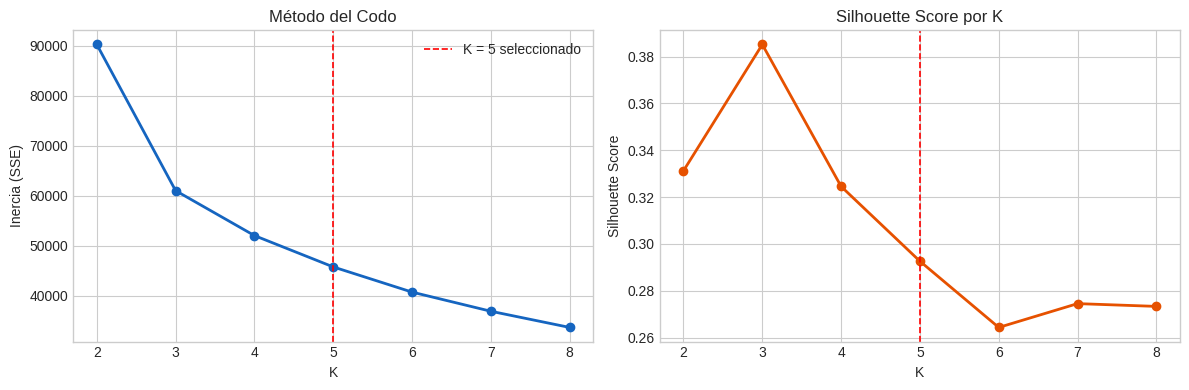

Silhouette por K: {2: 0.331, 3: 0.385, 4: 0.325, 5: 0.293, 6: 0.264, 7: 0.275, 8: 0.273}


In [15]:
# ── Elbow + Silhouette para determinar K ──────────────────────────────
K_RANGE  = range(2, 9)
inertias = []
silhs    = []

for k in K_RANGE:
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_cl_sc)
    inertias.append(km_tmp.inertia_)
    silhs.append(
        silhouette_score(X_cl_sc, labels_tmp,
                         sample_size=5_000, random_state=RANDOM_SEED)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), inertias, "o-", color="#1565C0", lw=2)
axes[0].set(xlabel="K", ylabel="Inercia (SSE)", title="Método del Codo")
axes[0].axvline(5, color="red", lw=1.2, ls="--", label="K = 5 seleccionado")
axes[0].legend()

axes[1].plot(list(K_RANGE), silhs, "o-", color="#E65100", lw=2)
axes[1].set(xlabel="K", ylabel="Silhouette Score", title="Silhouette Score por K")
axes[1].axvline(5, color="red", lw=1.2, ls="--")

plt.tight_layout()
plt.savefig('IMG/kmeans.png', bbox_inches='tight')
plt.show()

print("Silhouette por K:", {k: round(s, 3) for k, s in zip(K_RANGE, silhs)})

In [16]:
# ── KMeans K = 5 ──────────────────────────────────────────────────────
K_FINAL  = 5
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_SEED, n_init=20)
df_cl["cluster"] = km_final.fit_predict(X_cl_sc)

# Centroides en escala original
centroides = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=FEATS_CLUSTER,
).round(0)
centroides.index.name = "cluster"

print("=== Centroides (escala original) ===")
print(centroides.to_string())

if "segmento" in df_cl.columns:
    print("\n=== Distribución de segmentos por cluster ===")
    print(
        df_cl.groupby(["cluster", "segmento"], observed=True)
             .size()
             .unstack(fill_value=0)
             .to_string()
    )

=== Centroides (escala original) ===
            price  antiguedad        km     cv      cc
cluster                                               
0         48341.0         8.0  111435.0  362.0  2971.0
1          7318.0        18.0  225713.0  134.0  1727.0
2         15746.0         6.0   81187.0  115.0  1337.0
3        187122.0         4.0   32694.0  568.0  3878.0
4         30657.0         4.0   67367.0  185.0  1848.0

=== Distribución de segmentos por cluster ===
segmento  Utilitario  plus  premium
cluster                            
0                155   806      446
1               5254  2476        3
2               8255  1441        0
3                  0     0      164
4               2665  3229      144


In [17]:
# ── Naming heurístico de perfiles ─────────────────────────────────────
# IMPORTANTE: revisar manualmente si cambia K, RANDOM_SEED o el dataset.
# La siguiente función asigna nombres a partir de los valores del centroide.

def auto_nombre_perfil(row) -> str:
    """Heurística sobre centroides. Ajustar tras ejecutar y revisar."""
    precio     = row["price"]
    antiguedad = row["antiguedad"]
    km         = row["km"]
    cv         = row["cv"]

    if precio > 100_000:
        return "Premium / Ultra-Lujo"
    if precio > 40_000:
        return "plus Moderno"
    if precio > 20_000 and antiguedad <= 5:
        return "Familiar Alto Rango"
    if km > 180_000 and precio < 10_000:
        return "Alto Kilometraje"
    if precio < 6_000 and antiguedad > 15:
        return "Clásico Económico"
    return "Utilitario Estándar"

centroides["nombre_perfil"] = centroides.apply(auto_nombre_perfil, axis=1)

print("=== Nombres auto-asignados (revisar manualmente) ===")
for idx, row in centroides.iterrows():
    print(
        f"  Cluster {idx}: '{row['nombre_perfil']}'  "
        f"→  precio={row['price']:.0f}€  "
        f"edad={row['antiguedad']:.0f}a  "
        f"km={row['km']:.0f}  cv={row['cv']:.0f}"
    )

nombre_map = centroides["nombre_perfil"].to_dict()
df_cl["nombre_perfil"] = df_cl["cluster"].map(nombre_map)

=== Nombres auto-asignados (revisar manualmente) ===
  Cluster 0: 'plus Moderno'  →  precio=48341€  edad=8a  km=111435  cv=362
  Cluster 1: 'Alto Kilometraje'  →  precio=7318€  edad=18a  km=225713  cv=134
  Cluster 2: 'Utilitario Estándar'  →  precio=15746€  edad=6a  km=81187  cv=115
  Cluster 3: 'Premium / Ultra-Lujo'  →  precio=187122€  edad=4a  km=32694  cv=568
  Cluster 4: 'Familiar Alto Rango'  →  precio=30657€  edad=4a  km=67367  cv=185


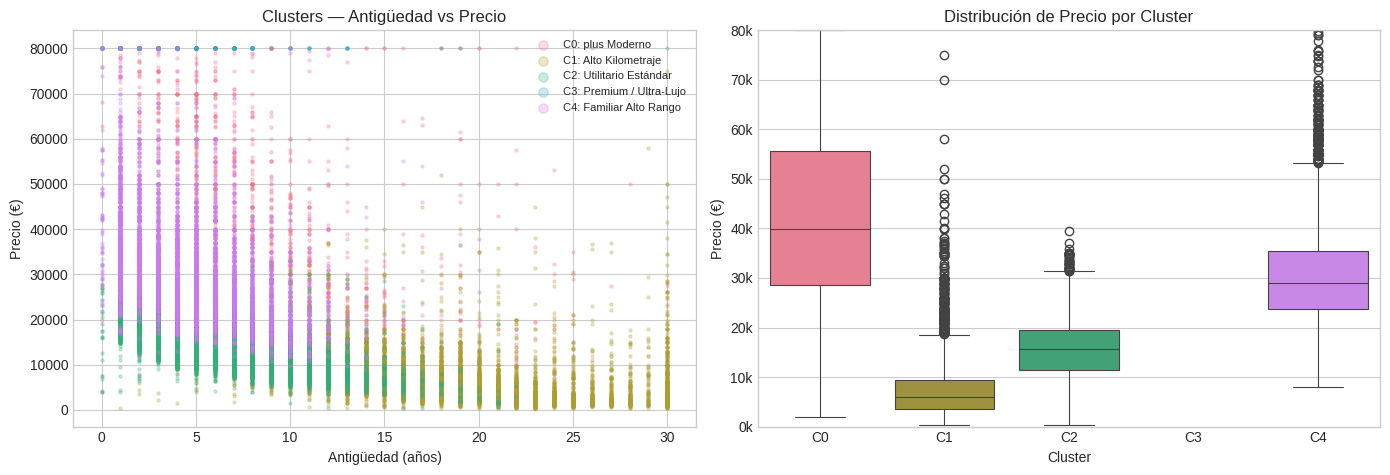

In [18]:
# ── Visualización ─────────────────────────────────────────────────────
palette = sns.color_palette("husl", K_FINAL)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Scatter antigüedad vs precio —
for k in range(K_FINAL):
    g = df_cl[df_cl["cluster"] == k]
    axes[0].scatter(
        g["antiguedad"].clip(upper=30),
        g["price"].clip(upper=80_000),
        alpha=0.25, s=5,
        label=f"C{k}: {nombre_map[k]}",
        color=palette[k],
    )
axes[0].set_xlabel("Antigüedad (años)")
axes[0].set_ylabel("Precio (€)")
axes[0].set_title("Clusters — Antigüedad vs Precio")
axes[0].legend(markerscale=3, fontsize=8)

# — Boxplot precio por cluster —
df_cl["cluster_label"] = df_cl["cluster"].map(lambda k: f"C{k}")
order = [f"C{i}" for i in range(K_FINAL)]
sns.boxplot(
    data=df_cl[df_cl["price"] <= 80_000],
    x="cluster_label", y="price",
    order=order, palette=palette, ax=axes[1], linewidth=0.8,
)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000:.0f}k")
)
axes[1].set_ylim(0, 80_000)
axes[1].set_title("Distribución de Precio por Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Precio (€)")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 7. Feature Store — Exportación a Producción

Consolidación de todos los outputs ML en un único `DataFrame`
como tabla de staging (`stg_ml_features`), y unirla vía dbt a la tabla de hechos principal.

### Esquema de producción

| Columna | Origen | Tipo | Descripción |
|---------|--------|------|-------------|
| `id` | — | PK | Identificador del anuncio |
| `segmento` | — | str | Utilitario / plus / Premium |
| `precio_predicho` | T1 | int | Precio estimado por RF (€) |
| `precio_real` | T1 | int | Precio original del anuncio |
| `residuo_precio` | T3 | int | `precio_predicho − precio_real` |
| `residuo_z` | T3 | float | Residuo en unidades de desviación estándar |
| `score_iso` | T3 | float | Puntuación IsolationForest (más negativo → más anómalo) |
| `etiqueta_anomalia` | T3 | str | ganga / caro / anomalia_general / normal |
| `prob_plus` | T2 | float | P(plus) ∈ [0, 1] según HistGBC |
| `cluster_id` | T4 | int | Índice del cluster KMeans |
| `cluster_nombre` | T4 | str | Perfil interpretable del cluster |

In [19]:
# ── Probabilidades plus sobre todo df_reg ──────────────────────────
# Se aplican los mismos encoders (oe_clf) entrenados en Task 2
X_fs_clf = df_reg[FEATS_CLF].copy()
X_fs_clf[FEATS_CAT_LOC] = oe_clf.transform(
    X_fs_clf[FEATS_CAT_LOC].astype(str)
)
# FEATS_NUM + TARGET: se dejan con NaN (HistGBC los gestiona nativamente)
prob_plus_full = hgbc.predict_proba(X_fs_clf)[:, 1]

# ── Construcción del Feature Store ────────────────────────────────────
df_fs = df_reg[["id", "segmento"]].copy().reset_index(drop=True)
df_fs["precio_predicho"]    = precio_predicho.round(0).astype(int)
df_fs["precio_real"]        = precio_real.round(0).astype(int)
df_fs["residuo_precio"]     = residuo.round(0).astype(int)
df_fs["residuo_z"]          = np.round(residuo_z, 4)
df_fs["score_iso"]          = np.round(iso_scores, 4)
df_fs["etiqueta_anomalia"]  = etiquetas
df_fs["prob_plus"]       = np.round(prob_plus_full, 4)

# Merge clusters (df_cl cubre todos los segmentos incluyendo Premium, pero solo los anuncios con precio válido)
cl_map = (
    df_cl[["id", "cluster", "nombre_perfil"]]
    .rename(columns={"cluster": "cluster_id", "nombre_perfil": "cluster_nombre"})
)
df_fs = df_fs.merge(cl_map, on="id", how="left")

print(f"Feature Store: {df_fs.shape[0]:,} filas × {df_fs.shape[1]} columnas")
print("\nDtypes:")
print(df_fs.dtypes.to_string())
print("\nPrimeras filas:")
print(df_fs.head(5).to_string(index=False))

Feature Store: 24,281 filas × 11 columnas

Dtypes:
id                     int64
segmento              object
precio_predicho        int64
precio_real            int64
residuo_precio         int64
residuo_z            float64
score_iso            float64
etiqueta_anomalia     object
prob_plus            float64
cluster_id             int32
cluster_nombre        object

Primeras filas:
      id   segmento  precio_predicho  precio_real  residuo_precio  residuo_z  score_iso etiqueta_anomalia  prob_plus  cluster_id      cluster_nombre
62479826 Utilitario            18647        17790             857     0.2553    -0.4315            normal     0.0047           2 Utilitario Estándar
62595348       plus            19372        14900            4472     1.3114    -0.4761            normal     0.6135           4 Familiar Alto Rango
62646888       plus             3739         6790           -3051    -0.8864    -0.4836            normal     0.4057           1    Alto Kilometraje
70042922       pl

In [20]:
# ── Exportar y resumen ejecutivo ──────────────────────────────────────
df_fs.to_csv(OUTPUT_PATH, index=False)
print(f"  Feature Store exportado → {OUTPUT_PATH}")
print()

print("═" * 52)
print("  RESUMEN EJECUTIVO DEL PIPELINE")
print("═" * 52)
print(f"  Anuncios procesados (Util + plus): {len(df_fs):,}")
print()
print("  — T1: Regresión de Precio —")
print(f"  R² en test   : {r2:.4f}")
print(f"  MAE en test  : {mae:,.0f} €")
print(f"  MAPE en test : {mape:.1f} %")
print()
print("  — T2: Clasificación plus (sin marca) —")
print(f"  ROC-AUC  : {auc:.4f}")
print(f"  F1-Score : {f1:.4f}")
print()
print("  — T3: Anomalías —")
for label, cnt in pd.Series(etiquetas).value_counts().items():
    pct = cnt / len(etiquetas) * 100
    print(f"  {label:<22}: {cnt:>5,}  ({pct:.1f}%)")
print()
print("  — T4: Perfiles de mercado —")
for k, nombre in nombre_map.items():
    n      = (df_cl["cluster"] == k).sum()
    p_med  = df_cl.loc[df_cl["cluster"] == k, "price"].median()
    print(f"  C{k} '{nombre}': {n:,} coches  |  mediana {p_med:,.0f} €")
print("═" * 52)

  Feature Store exportado → ml_features.csv

════════════════════════════════════════════════════
  RESUMEN EJECUTIVO DEL PIPELINE
════════════════════════════════════════════════════
  Anuncios procesados (Util + plus): 24,281

  — T1: Regresión de Precio —
  R² en test   : 0.8772
  MAE en test  : 2,551 €
  MAPE en test : 25.1 %

  — T2: Clasificación plus (sin marca) —
  ROC-AUC  : 0.9540
  F1-Score : 0.8258

  — T3: Anomalías —
  normal                : 21,190  (87.3%)
  caro                  : 1,411  (5.8%)
  anomalia_general      :   954  (3.9%)
  ganga                 :   726  (3.0%)

  — T4: Perfiles de mercado —
  C0 'plus Moderno': 1,407 coches  |  mediana 44,490 €
  C1 'Alto Kilometraje': 7,733 coches  |  mediana 5,999 €
  C2 'Utilitario Estándar': 9,696 coches  |  mediana 15,630 €
  C3 'Premium / Ultra-Lujo': 164 coches  |  mediana 161,945 €
  C4 'Familiar Alto Rango': 6,038 coches  |  mediana 28,900 €
════════════════════════════════════════════════════
